# 유사도 분석

**WordNet**
WordNet은 영어 어휘를 체계적으로 정리한 대형 어휘 데이터베이스로, 단어 간의 관계(의미적, 개념적 관계)를 나타내기 위해 설계된 자연어 처리(NLP)에서 자주 사용하는 리소스입니다. Princeton University에서 개발되었으며, 다양한 NLP 작업에 활용됩니다.

1. 단어 그룹화(Synsets):

WordNet은 단어들을 Synset(Synonym Set, 동의어 집합)이라는 단위로 그룹화합니다.
하나의 Synset은 서로 비슷한 의미를 가진 단어들의 집합입니다.
예: "car", "automobile"은 같은 Synset에 속하며, 동일한 의미를 가집니다.

2. 단어 간 관계(Relations):

단어 간의 다양한 관계를 제공합니다:
- 동의 관계(Synonymy): Synset을 통해 동의어 제공.
- 반의 관계(Antonymy): 단어의 반대 의미 제공.
- 상하위 관계(Hyponymy & Hypernymy): 특정 단어가 다른 단어의 하위 개념인지 상위 개념인지 나타냅니다. 예: "dog"는 "animal"의 하위 개념(Hyponym)입니다.
- 부분-전체 관계(Meronymy & Holonymy): 단어가 다른 단어의 일부인지 전체인지 나타냅니다. 예: "wheel"은 "car"의 일부(Meronym)입니다.

3. 품사 정보:

WordNet은 단어의 품사(Part of Speech) 정보를 포함합니다:
명사(Noun), 동사(Verb), 형용사(Adjective), 부사(Adverb)
정의와 예문(Gloss & Example):

4. WordNet의 한계
- 동적 언어 데이터 부족: WordNet은 고정된 구조로 구성되어 있어 최신 단어나 표현을 포함하지 않을 수 있습니다.
- 문맥 정보 부족: 단어의 의미를 Synset에 따라 정리했지만, 실제 문맥에서의 의미를 충분히 반영하지 못할 수 있습니다.


In [48]:
import nltk
from nltk.corpus import wordnet as wn
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [49]:
# 1. Synset 검색
print('-----Car Synsets Search-----')
synsets = wn.synsets("car")  # "car"와 관련된 Synset 목록 반환, 5개의 다른 car 의미 출력
print('Car synsets : ', synsets)

-----Car Synsets Search-----
Car synsets :  [Synset('car.n.01'), Synset('car.n.02'), Synset('car.n.03'), Synset('car.n.04'), Synset('cable_car.n.01')]


In [50]:
# 2. Synset 정보
print('\n-----Car Synsets Information #1-----')
car_synset = wn.synset("car.n.01")  # 특정 Synset 선택
print('Car.n.01 Synset Definition : ', car_synset.definition())  # 정의 출력
print('Car.n.01 Synset Example : ', car_synset.examples())    # 예문 출력

print('-----Car Synsets Information #2-----')
car_synset = wn.synset("car.n.02")  # 특정 Synset 선택
print('Car.n.02 Synset Definition : ', car_synset.definition())  # 정의 출력
print('Car.n.02 Synset Example : ', car_synset.examples())       # 예문 출력


-----Car Synsets Information #1-----
Car.n.01 Synset Definition :  a motor vehicle with four wheels; usually propelled by an internal combustion engine
Car.n.01 Synset Example :  ['he needs a car to get to work']
-----Car Synsets Information #2-----
Car.n.02 Synset Definition :  a wheeled vehicle adapted to the rails of railroad
Car.n.02 Synset Example :  ['three cars had jumped the rails']


lemmas() 는 lemma(단어 원형) 객체들을 반환합니다.

In [52]:
# 3. 동의어와 반의어
print('\n-----Relative Synonym and Antonym-----')
relative_synset = wn.synset("relative.a.01")  # 특정 Synset 선택

# 1) 동의어 목록 (문자열만)
synonyms = [lemma.name() for lemma in relative_synset.lemmas()]
print("[Relative] Synonym List:", synonyms)

# 2) 첫 번째 동의어
first_synonym = relative_synset.lemmas()[0].name()
print("First Synonym:", first_synonym)

# 3) 첫 번째 반의어
antonym = relative_synset.lemmas()[0].antonyms()
if antonym:
    first_antonym = antonym[0].name()
else:
    first_antonym = None
print("First Antonym:", first_antonym)


-----Relative Synonym and Antonym-----
[Relative] Synonym List: ['relative', 'comparative']
First Synonym: relative
First Antonym: absolute


In [ ]:
# 4. 상위 및 하위 개념
print('\n-----Car Synsets Hypernyms and Hyponyms-----')
print('Car Hypernyms : ', car_synset.hypernyms())  # 상위 개념
print('Car Hyponyms : ', car_synset.hyponyms())    # 하위 개념


-----Car Synsets Hypernyms and Hyponyms-----
Car Hypernyms :  [Synset('wheeled_vehicle.n.01')]
Car Hyponyms :  [Synset('baggage_car.n.01'), Synset('freight_car.n.01'), Synset('slip_coach.n.01'), Synset('handcar.n.01'), Synset('tender.n.04'), Synset('mail_car.n.01'), Synset('cabin_car.n.01'), Synset('guard's_van.n.01'), Synset('club_car.n.01'), Synset('passenger_car.n.01'), Synset('van.n.03')]


In [ ]:
# 5. 경로 길이(Path Similarity)
print('\n-----Path Similarity-----')
dog = wn.synset("dog.n.01")
cat = wn.synset("cat.n.01")
car = wn.synset("car.n.01")
print('Similarity between dog and cat : ', dog.path_similarity(cat))  # "dog"와 "cat"의 유사도 계산
print('Similarity between car and dog : ', dog.path_similarity(car))  # "dog"와 "cat"의 유사도 계산


-----Path Similarity-----
Similarity between dog and cat :  0.2
Similarity between car and dog :  0.07692307692307693


# 모듈25

**텍스트 유사도**
- 텍스트 쌍에 대한 유사도 계산
- 유클리디안 거리(Euclidean Distance) : 유클리디안 거리를 사용하여 두 벡터 간의 차이를 계산하며, 거리가 짧을 수록 두 벡터가 더 유사하다고 판단
- 코사인 유사도(Cosine Similarity) : 벡터 표현 사이의 각도에 대한 코사인 값을 사용. BoW와 TF-IDF 행렬은 텍스트에 대한 벡터 표현으로 활용 가능
- 자카드 유사도(Jaccard Similarity) : 두 텍스트 문서 사이에 공통된 용어의 수와 해당 텍스트에 존재하는 총 고유용어 수의 비율을 사용

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
s1 = 'The iPhone was made by a company called Apple.'
s2 = 'I love Apple iPhone.'
s3 = 'Facebook was created by Meta company.'
s4 = 'iPhone and Galaxy phones are famous.'
s5 = 'I like apple and banana'

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus = [s1, s2, s3, s4, s5]
vector = CountVectorizer(stop_words = 'english')
bow = vector.fit_transform(corpus)
print('단어장 :', vector.vocabulary_) # value는 알파벳 순서
#print(type(vector.vocabulary_))
columns = []

for k, v in sorted(vector.vocabulary_.items(), key = lambda item : item[1]) :
  columns.append(k)

print(columns)
df = pd.DataFrame(bow.toarray(), index = corpus, columns = columns)
df

단어장 : {'iphone': 8, 'company': 3, 'called': 2, 'apple': 0, 'love': 10, 'facebook': 5, 'created': 4, 'meta': 11, 'galaxy': 7, 'phones': 12, 'famous': 6, 'like': 9, 'banana': 1}
['apple', 'banana', 'called', 'company', 'created', 'facebook', 'famous', 'galaxy', 'iphone', 'like', 'love', 'meta', 'phones']


,apple,banana,called,company,created,facebook,famous,galaxy,iphone,like,love,meta,phones
The iPhone was made by a company called Apple.,1,0,1,1,0,0,0,0,1,0,0,0,0
I love Apple iPhone.,1,0,0,0,0,0,0,0,1,0,1,0,0
Facebook was created by Meta company.,0,0,0,1,1,1,0,0,0,0,0,1,0
iPhone and Galaxy phones are famous.,0,0,0,0,0,0,1,1,1,0,0,0,1
I like apple and banana,1,1,0,0,0,0,0,0,0,1,0,0,0


**bag of words 로 유사성 판단**
- 단순 백터 곱

In [ ]:
import numpy as np

s1_bow = np.array(df.iloc[0])
s2_bow = np.array(df.iloc[1])
s3_bow = np.array(df.iloc[2])
s4_bow = np.array(df.iloc[3])
s5_bow = np.array(df.iloc[4])

print('s1:', s1_bow)
print('s2:', s2_bow)
print('s3:', s3_bow)
print('s4:', s4_bow)
print('s5:', s5_bow)
print('-'*100)

print('s1 - s2 :' ,s1_bow * s2_bow, sum(s1_bow * s2_bow))
print('s1 - s3 :' ,s1_bow * s3_bow, sum(s1_bow * s3_bow))
print('s1 - s4 :' ,s1_bow * s4_bow, sum(s1_bow * s4_bow))
print('s1 - s5 :' ,s1_bow * s5_bow, sum(s1_bow * s5_bow))
print('s2 - s3 :' ,s2_bow * s3_bow, sum(s2_bow * s3_bow))
print('s2 - s4 :' ,s2_bow * s4_bow, sum(s2_bow * s4_bow))
print('s2 - s5 :' ,s2_bow * s5_bow, sum(s2_bow * s5_bow))
print('s3 - s4 :' ,s3_bow * s4_bow, sum(s3_bow * s4_bow))
print('s3 - s5 :' ,s3_bow * s5_bow, sum(s3_bow * s5_bow))
print('s4 - s5 :' ,s4_bow * s5_bow, sum(s4_bow * s5_bow))


s1: [1 0 1 1 0 0 0 0 1 0 0 0 0]
s2: [1 0 0 0 0 0 0 0 1 0 1 0 0]
s3: [0 0 0 1 1 1 0 0 0 0 0 1 0]
s4: [0 0 0 0 0 0 1 1 1 0 0 0 1]
s5: [1 1 0 0 0 0 0 0 0 1 0 0 0]
----------------------------------------------------------------------------------------------------
s1 - s2 : [1 0 0 0 0 0 0 0 1 0 0 0 0] 2
s1 - s3 : [0 0 0 1 0 0 0 0 0 0 0 0 0] 1
s1 - s4 : [0 0 0 0 0 0 0 0 1 0 0 0 0] 1
s1 - s5 : [1 0 0 0 0 0 0 0 0 0 0 0 0] 1
s2 - s3 : [0 0 0 0 0 0 0 0 0 0 0 0 0] 0
s2 - s4 : [0 0 0 0 0 0 0 0 1 0 0 0 0] 1
s2 - s5 : [1 0 0 0 0 0 0 0 0 0 0 0 0] 1
s3 - s4 : [0 0 0 0 0 0 0 0 0 0 0 0 0] 0
s3 - s5 : [0 0 0 0 0 0 0 0 0 0 0 0 0] 0
s4 - s5 : [0 0 0 0 0 0 0 0 0 0 0 0 0] 0


**bag of words 로 유사성 판단**
- 유클리디안 거리

In [ ]:
import numpy as np

# 유클리디안 거리 계산
print('s1-s2 :', np.linalg.norm(s1_bow - s2_bow))
print('s1-s3 :', np.linalg.norm(s1_bow - s3_bow))
print('s1-s4 :', np.linalg.norm(s1_bow - s4_bow))
print('s1-s5 :', np.linalg.norm(s1_bow - s5_bow))
print('s2-s3 :', np.linalg.norm(s2_bow - s3_bow))
print('s2-s4 :', np.linalg.norm(s2_bow - s4_bow))
print('s2-s5 :', np.linalg.norm(s2_bow - s5_bow))
print('s3-s4 :', np.linalg.norm(s3_bow - s4_bow))
print('s3-s5 :', np.linalg.norm(s3_bow - s5_bow))
print('s4-s5 :', np.linalg.norm(s4_bow - s5_bow))


s1-s2 : 1.7320508075688772
s1-s3 : 2.449489742783178
s1-s4 : 2.449489742783178
s1-s5 : 2.23606797749979
s2-s3 : 2.6457513110645907
s2-s4 : 2.23606797749979
s2-s5 : 2.0
s3-s4 : 2.8284271247461903
s3-s5 : 2.6457513110645907
s4-s5 : 2.6457513110645907


**bag of words 로 유사성 판단**
- Cosine 유사도

In [ ]:
import numpy as np

# 각 문장의 Bag of Words 벡터를 2차원 배열로 변환
bow_vectors = np.array([s1_bow, s2_bow, s3_bow, s4_bow, s5_bow])
#print(bow_vectors)
# 코사인 유사도 계산
cosine_sim_matrix = cosine_similarity(bow_vectors)

documents = [s1, s2, s3, s4, s5]
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=documents, columns=documents)

cosine_sim_df  # 큰 수일 수록 가깝다.


,The iPhone was made by a company called Apple.,I love Apple iPhone.,Facebook was created by Meta company.,iPhone and Galaxy phones are famous.,I like apple and banana
The iPhone was made by a company called Apple.,1.000000,0.577350,0.25,0.250000,0.288675
I love Apple iPhone.,0.577350,1.000000,0.00,0.288675,0.333333
Facebook was created by Meta company.,0.250000,0.000000,1.00,0.000000,0.000000
iPhone and Galaxy phones are famous.,0.250000,0.288675,0.00,1.000000,0.000000
I like apple and banana,0.288675,0.333333,0.00,0.000000,1.000000


TF-IDF 생성

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform([s1, s2, s3, s4, s5])

print(tfidf.vocabulary_)

columns = []

for k, v in sorted(vector.vocabulary_.items(), key = lambda item : item[1]) :
  columns.append(k)

s_tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=documents, columns=columns)
s_tfidf_df

{'iphone': 8, 'company': 3, 'called': 2, 'apple': 0, 'love': 10, 'facebook': 5, 'created': 4, 'meta': 11, 'galaxy': 7, 'phones': 12, 'famous': 6, 'like': 9, 'banana': 1}


,apple,banana,called,company,created,facebook,famous,galaxy,iphone,like,love,meta,phones
The iPhone was made by a company called Apple.,0.419559,0.00000,0.626477,0.505438,0.000000,0.000000,0.000000,0.000000,0.419559,0.00000,0.000000,0.000000,0.000000
I love Apple iPhone.,0.486240,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.486240,0.00000,0.726044,0.000000,0.000000
Facebook was created by Meta company.,0.000000,0.00000,0.000000,0.422242,0.523358,0.523358,0.000000,0.000000,0.000000,0.00000,0.000000,0.523358,0.000000
iPhone and Galaxy phones are famous.,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.538498,0.538498,0.360638,0.00000,0.000000,0.000000,0.538498
I like apple and banana,0.427993,0.63907,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.63907,0.000000,0.000000,0.000000


**TFIDF 로 유사성 판단**
- Cosine 유사도


In [ ]:
cosine_sim_matrix = cosine_similarity(tfidf_matrix.toarray())

# 결과를 데이터프레임으로 변환하여 보기 좋게 출력
documents = [s1, s2, s3, s4, s5]
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=documents, columns=documents)

cosine_sim_df

,The iPhone was made by a company called Apple.,I love Apple iPhone.,Facebook was created by Meta company.,iPhone and Galaxy phones are famous.,I like apple and banana
The iPhone was made by a company called Apple.,1.000000,0.408013,0.213417,0.151309,0.179568
I love Apple iPhone.,0.408013,1.000000,0.000000,0.175357,0.208107
Facebook was created by Meta company.,0.213417,0.000000,1.000000,0.000000,0.000000
iPhone and Galaxy phones are famous.,0.151309,0.175357,0.000000,1.000000,0.000000
I like apple and banana,0.179568,0.208107,0.000000,0.000000,1.000000


**Jacard 유사도 구하기**
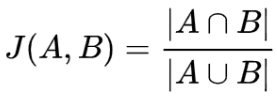
- lemmatization으로 단어들을 어근으로 구성
- lemmatization : 단어의 뿌리를 구하는 것. 문맥의 의미를 보고 단어의 뿌리를 판단

In [ ]:
from nltk import word_tokenize

def jaccard_similarity(d1, d2) :
  lemmatizer = WordNetLemmatizer()
  word1 = [lemmatizer.lemmatize(word.lower()) for word in word_tokenize(d1)]
  word2 = [lemmatizer.lemmatize(word.lower()) for word in word_tokenize(d2)]

  inter = len(set(word1).intersection(set(word2)))
  union = len(set(word1).union(set(word2)))

  return inter/union

In [ ]:
import nltk

nltk.download('wordnet')

print('s1-s2:', round(jaccard_similarity(s1, s2), 2))
print('s1-s3:', round(jaccard_similarity(s1, s3), 2))
print('s1-s4:', round(jaccard_similarity(s1, s4), 2))
print('s1-s5:', round(jaccard_similarity(s1, s5), 2))
print('s2-s3:', round(jaccard_similarity(s2, s3), 2))
print('s2-s4:', round(jaccard_similarity(s2, s4), 2))
print('s2-s5:', round(jaccard_similarity(s2, s5), 2))
print('s3-s4:', round(jaccard_similarity(s3, s4), 2))
print('s3-s5:', round(jaccard_similarity(s3, s5), 2))
print('s4-s5:', round(jaccard_similarity(s4, s5), 2))

s1-s2: 0.25
s1-s3: 0.31
s1-s4: 0.13
s1-s5: 0.07
s2-s3: 0.09
s2-s4: 0.2
s2-s5: 0.25
s3-s4: 0.08
s3-s5: 0.0
s4-s5: 0.09


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**SVD(Singular Value Decomposition)** : 특이값 분해

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

d1 = 'pizza'
d2 = 'pizza hamburger cookie'
d3 = 'hamburger'
d4 = 'ramen'
d5 = 'sushi'
d6 = 'ramen sushi'

corpus = [d1, d2, d3, d4, d5, d6]
#col_names = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']

# TF-IDF 벡터화
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)

# 단어 목록(컬럼 이름) 가져오기
vocab = tfidf.get_feature_names_out()
print(vocab)

# 데이터프레임 생성 (전치 행렬 사용)
df = pd.DataFrame(tfidf_matrix.T.toarray(), index=vocab, columns=corpus)

# TF-TDF 결과 출력
df

['cookie' 'hamburger' 'pizza' 'ramen' 'sushi']


,pizza,pizza hamburger cookie,hamburger,ramen,sushi,ramen sushi
cookie,0.0,0.653044,0.0,0.0,0.0,0.000000
hamburger,0.0,0.535506,1.0,0.0,0.0,0.000000
pizza,1.0,0.535506,0.0,0.0,0.0,0.000000
ramen,0.0,0.000000,0.0,1.0,0.0,0.707107
sushi,0.0,0.000000,0.0,0.0,1.0,0.707107


numpy.diag(values) 형태로 사용하면, 주어진 리스트(또는 1차원 배열)를 대각선 요소로 가지는 대각 행렬을 만든다

In [ ]:
# SVD
U, S, V = np.linalg.svd(df)

U = np.round(U, 1)
V = np.round(V, 1)

print('U vector :\n', U)
print('V vector :\n', V)
print('S vector :\n', S)
S_extended = np.zeros((V.shape[0], V.shape[0]))  # 6x6 행렬 생성, zero(가, 세). shape(세, 가)
S_extended[:len(S), :len(S)] = np.diag(S)  # 6개의 값을 대각선에 배치
#S_extended = np.diag(S)

# S 수정한 결과 출력
df = pd.DataFrame(S_extended)
print('\n대각행렬')
df

U vector :
 [[ 0.   0.3  0.   0.   0.9]
 [ 0.   0.7  0.  -0.7 -0.2]
 [ 0.   0.7  0.   0.7 -0.2]
 [ 0.7  0.  -0.7  0.   0. ]
 [ 0.7  0.   0.7  0.   0. ]]
V vector :
 [[-0.  -0.   0.   0.5  0.5  0.7]
 [ 0.5  0.7  0.5 -0.  -0.   0. ]
 [-0.  -0.   0.  -0.7  0.7  0. ]
 [ 0.7  0.  -0.7 -0.  -0.   0. ]
 [-0.5  0.7 -0.5 -0.  -0.   0. ]
 [ 0.   0.   0.  -0.5 -0.5  0.7]]
S vector :
 [1.41421356 1.32563931 1.         1.         0.49262606]

대각행렬


,0,1,2,3,4,5
0,1.414214,0.000000,0.0,0.0,0.000000,0.0
1,0.000000,1.325639,0.0,0.0,0.000000,0.0
2,0.000000,0.000000,1.0,0.0,0.000000,0.0
3,0.000000,0.000000,0.0,1.0,0.000000,0.0
4,0.000000,0.000000,0.0,0.0,0.492626,0.0
5,0.000000,0.000000,0.0,0.0,0.000000,0.0


In [ ]:
np.diag(S)

array([[1.41421356, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 1.32563931, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 1.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.49262606]])

In [ ]:
# 2개의 행렬 곱 결과 출력
result_matrix = np.matmul(S_extended, V)
df = pd.DataFrame(result_matrix,  columns=corpus)

df

,pizza,pizza hamburger cookie,hamburger,ramen,sushi,ramen sushi
0,0.000000,0.000000,0.000000,0.707107,0.707107,0.989949
1,0.662820,0.927948,0.662820,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,-0.700000,0.700000,0.000000
3,0.700000,0.000000,-0.700000,0.000000,0.000000,0.000000
4,-0.246313,0.344838,-0.246313,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


위의 결과에서 각 Document를 6개의 좌표로 표시할 수 있지만 편의상 2차원 좌표만 취해서 유사도를 확인한다

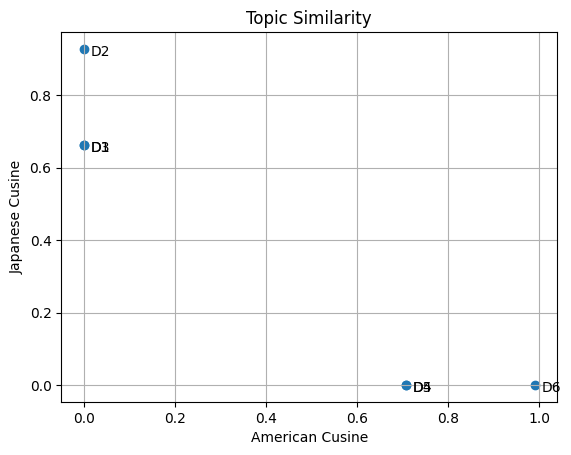

In [ ]:
# 두 개의 행을 선택 (예: 첫 번째와 두 번째 행)
x_coords = result_matrix[0, :]  # 첫 번째 행을 x 좌표로 사용
y_coords = result_matrix[1, :]  # 두 번째 행을 y 좌표로 사용

# 산점도 그리기
plt.scatter(x_coords, y_coords)

col_names = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']

for i, txt in enumerate(col_names):
    plt.annotate(txt, (x_coords[i], y_coords[i]), textcoords="offset points", xytext=(5,-5), ha='left')

plt.xlabel('American Cusine')
plt.ylabel('Japanese Cusine')
plt.title('Topic Similarity')
plt.grid(True)
plt.show()

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.0 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# 예제 문장들
sentences = [['이', '영화', '정말', '재미있다'],
             ['이', '책', '정말', '재미있다'],
             ['이', '소설',  '길다']]


# Word2Vec 모델 학습, window - 컨텍스트 윈도우크기, min_count 값 밑으로 등장한 단어는 무시
word2vec = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

print("W2V index to key ", word2vec.wv.index_to_key) # Word2Vec 모델의 단어 목록 빈도순

# 단어 인덱스 매핑
word_index = {word: i for i, word in enumerate(word2vec.wv.index_to_key)}
index_word = {i: word for word, i in word_index.items()}
print("Index - word", index_word)

# 시퀀스 데이터 생성
def create_sequences(sentences, word_index, seq_length):
    sequences = []
    for sentence in sentences:
        encoded = [word_index[word] for word in sentence]  # 문장을 숫자로 인코딩
        print(encoded)
        for i in range(1, len(encoded)):
            sequence = encoded[:i+1]   # 2개 단어부터 하나씩 증가하면서 sequence에 저장
            sequences.append(sequence) # for 문 한 번 실행때 마다 단어가 2, 3, 4개 리스트에 추가됨
    sequences = pad_sequences(sequences, maxlen=seq_length, padding='pre') # 시퀀스들의 길이가 다를 경우 pre(앞)에 0을 채워 길이를 맞춤
    print(sequences)
    X, y = sequences[:, :-1], sequences[:, -1]  # 시퀀스에서 마지막 단어를 y(출력)로 설정하고, 나머지 부분을 X(입력)
    y = to_categorical(y, num_classes=len(word_index))    # one-hot encoding
    return X, y

seq_length = 4
X, y = create_sequences(sentences, word_index, seq_length)
print('X :\n',  X)
print('y :\n', y)


W2V index to key  ['이', '재미있다', '정말', '길다', '소설', '책', '영화']
Index - word {0: '이', 1: '재미있다', 2: '정말', 3: '길다', 4: '소설', 5: '책', 6: '영화'}
[0, 6, 2, 1]
[0, 5, 2, 1]
[0, 4, 3]
[[0 0 0 6]
 [0 0 6 2]
 [0 6 2 1]
 [0 0 0 5]
 [0 0 5 2]
 [0 5 2 1]
 [0 0 0 4]
 [0 0 4 3]]
X :
 [[0 0 0]
 [0 0 6]
 [0 6 2]
 [0 0 0]
 [0 0 5]
 [0 5 2]
 [0 0 0]
 [0 0 4]]
y :
 [[0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]]


model.add(LSTM(50, input_shape=(seq_length-1, 100))):

LSTM 레이어:

LSTM은 시퀀스 데이터를 처리하는데 자주 사용되는 순환 신경망(RNN)의 한 유형입니다. 이 레이어는 시간에 따른 종속성이 있는 데이터를 처리할 수 있는 능력을 가지고 있습니다.

50: LSTM 레이어의 유닛 수, 즉 LSTM이 학습할 은닉 상태(hidden state)의 차원을 의미합니다. 이 값이 클수록 모델의 학습 능력은 높아지지만, 계산 비용도 증가합니다.

input_shape=(seq_length-1, 100):

input_shape는 모델에 입력되는 데이터의 형상을 정의합니다. 여기서 seq_length-1은 입력 시퀀스의 길이를 의미하고, 100은 각 단어가 벡터로 표현된 차원 크기를 의미합니다.
예를 들어, 시퀀스 길이가 4인 경우(3개의 입력 단어와 1개의 출력 단어)라면, 입력 형태는 (3, 100)이 됩니다.

model.add(Dense(len(word_index), activation='softmax')):

Dense 레이어:
len(word_index): Dense 레이어의 유닛 수는 word_index의 길이와 동일하며, 이는 예측할 수 있는 단어의 총 개수를 의미합니다. 즉, 출력 레이어의 각 뉴런은 어휘 사전의 각 단어에 해당합니다.

요약

이 모델은 LSTM을 사용하여 시퀀스 데이터를 입력받아 다음 단어를 예측하는 모델을 구축합니다.
입력 시퀀스는 (seq_length-1, 100) 형태의 2차원 배열로 표현되며, 출력은 예측된 단어에 대한 확률 분포입니다.
모델은 categorical crossentropy 손실 함수를 사용하여 학습되며, Adam 옵티마이저를 통해 최적화됩니다.
학습 과정에서 모델의 정확도를 모니터링하여 성능을 평가합니다.

In [ ]:
X

array([[0, 0, 0],
       [0, 0, 6],
       [0, 6, 2],
       [0, 0, 0],
       [0, 0, 5],
       [0, 5, 2],
       [0, 0, 0],
       [0, 0, 4]], dtype=int32)

word2vec.wv는 **Word2Vec 모델에서 학습된 단어 벡터(Word Vectors)**에 접근하는 KeyedVectors 객체입니다

In [ ]:
print(type(word2vec.wv))
print(word2vec.wv['정말', '길다']) # 단어 하나당 100차원

<class 'gensim.models.keyedvectors.KeyedVectors'>
[[ 9.4563962e-05  3.0773198e-03 -6.8126451e-03 -1.3754654e-03
   7.6685809e-03  7.3464094e-03 -3.6732971e-03  2.6427018e-03
  -8.3171297e-03  6.2054861e-03 -4.6373224e-03 -3.1641065e-03
   9.3113566e-03  8.7338570e-04  7.4907029e-03 -6.0740625e-03
   5.1605068e-03  9.9228229e-03 -8.4573915e-03 -5.1356913e-03
  -7.0648370e-03 -4.8626517e-03 -3.7785638e-03 -8.5361991e-03
   7.9556061e-03 -4.8439382e-03  8.4236134e-03  5.2625705e-03
  -6.5500261e-03  3.9578713e-03  5.4701497e-03 -7.4265362e-03
  -7.4057197e-03 -2.4752307e-03 -8.6257253e-03 -1.5815723e-03
  -4.0343284e-04  3.2996845e-03  1.4418805e-03 -8.8142155e-04
  -5.5940580e-03  1.7303658e-03 -8.9737179e-04  6.7936908e-03
   3.9735902e-03  4.5294715e-03  1.4343059e-03 -2.6998555e-03
  -4.3668128e-03 -1.0320747e-03  1.4370275e-03 -2.6460087e-03
  -7.0737829e-03 -7.8053069e-03 -9.1217868e-03 -5.9351693e-03
  -1.8474245e-03 -4.3238713e-03 -6.4606704e-03 -3.7173224e-03
   4.2891586e-03 -3.

X_vectors = np.array([[word2vec.wv[index_word[idx]] for idx in seq]

이 코드 줄은 Word2Vec 모델을 사용하여 텍스트 데이터를 단어 임베딩 벡터로 변환하는 과정을 나타냅니다. 이를 통해 텍스트 데이터인 X를 RNN, LSTM, 또는 다른 딥러닝 모델에서 사용할 수 있는 형식으로 준비합니다.

In [ ]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, LSTM
import numpy as np
from keras.preprocessing.sequence import pad_sequences

# RNN 모델 정의
model = Sequential()
model.add(SimpleRNN(50, input_shape=(seq_length-1, 100)))
model.add(Dense(len(word_index), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Word2Vec 임베딩을 시퀀스 모델의 입력으로 사용
# X의 각 줄의 단어들을 word2vec.wv[] 으로 100차원 데이터로 만든다
X_vectors = np.array([[word2vec.wv[index_word[idx]] for idx in seq] for seq in X])
print(X_vectors.shape)

# 모델 학습
model.fit(X_vectors, y, epochs=100, verbose=2)

(8, 3, 100)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 - 2s - 2s/step - accuracy: 0.2500 - loss: 1.9378
Epoch 2/100
1/1 - 0s - 42ms/step - accuracy: 0.3750 - loss: 1.9324
Epoch 3/100
1/1 - 0s - 48ms/step - accuracy: 0.3750 - loss: 1.9270
Epoch 4/100
1/1 - 0s - 40ms/step - accuracy: 0.5000 - loss: 1.9215
Epoch 5/100
1/1 - 0s - 45ms/step - accuracy: 0.5000 - loss: 1.9160
Epoch 6/100
1/1 - 0s - 45ms/step - accuracy: 0.5000 - loss: 1.9102
Epoch 7/100
1/1 - 0s - 44ms/step - accuracy: 0.5000 - loss: 1.9043
Epoch 8/100
1/1 - 0s - 45ms/step - accuracy: 0.5000 - loss: 1.8982
Epoch 9/100
1/1 - 0s - 42ms/step - accuracy: 0.5000 - loss: 1.8919
Epoch 10/100
1/1 - 0s - 42ms/step - accuracy: 0.5000 - loss: 1.8853
Epoch 11/100
1/1 - 0s - 47ms/step - accuracy: 0.5000 - loss: 1.8784
Epoch 12/100
1/1 - 0s - 45ms/step - accuracy: 0.5000 - loss: 1.8713
Epoch 13/100
1/1 - 0s - 56ms/step - accuracy: 0.5000 - loss: 1.8640
Epoch 14/100
1/1 - 0s - 46ms/step - accuracy: 0.5000 - loss: 1.8563
Epoch 15/100
1/1 - 0s - 41ms/step - accuracy: 0.5000 - loss: 1.8484
Epo

In [ ]:
# 다음 단어 예측
def predict_next_word(model, word2vec, word_index, text, seq_length):
    encoded = [word_index[word] for word in text.split()]
    encoded = pad_sequences([encoded], maxlen=seq_length-1, padding='pre')
    print(encoded)
    encoded_vectors = np.array([[word2vec.wv[index_word[idx]] for idx in encoded[0]]])
    predicted = model.predict(encoded_vectors, verbose=0)
    return index_word[np.argmax(predicted)]

text = '이 소설 정말'
next_word = predict_next_word(model, word2vec, word_index, text, seq_length)
print(f'다음 단어 예측: {next_word}')


[[0 4 2]]
다음 단어 예측: 재미있다


In [ ]:
# LSTM 모델 정의
model = Sequential()
model.add(LSTM(50, input_shape=(seq_length-1, 100)))
model.add(Dense(len(word_index), activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Word2Vec 임베딩을 시퀀스 모델의 입력으로 사용
X_vectors = np.array([[word2vec.wv[index_word[idx]] for idx in seq] for seq in X])
print('X_vectors :\n', len(X_vectors))
# 모델 학습
model.fit(X_vectors, y, epochs=100, verbose=2)


X_vectors :
 8
Epoch 1/100
1/1 - 2s - 2s/step - accuracy: 0.3750 - loss: 1.9447
Epoch 2/100
1/1 - 0s - 43ms/step - accuracy: 0.3750 - loss: 1.9428
Epoch 3/100
1/1 - 0s - 46ms/step - accuracy: 0.2500 - loss: 1.9409
Epoch 4/100
1/1 - 0s - 46ms/step - accuracy: 0.2500 - loss: 1.9390
Epoch 5/100
1/1 - 0s - 45ms/step - accuracy: 0.2500 - loss: 1.9370
Epoch 6/100
1/1 - 0s - 46ms/step - accuracy: 0.2500 - loss: 1.9351
Epoch 7/100
1/1 - 0s - 45ms/step - accuracy: 0.2500 - loss: 1.9331
Epoch 8/100
1/1 - 0s - 45ms/step - accuracy: 0.2500 - loss: 1.9310
Epoch 9/100
1/1 - 0s - 44ms/step - accuracy: 0.2500 - loss: 1.9290
Epoch 10/100
1/1 - 0s - 44ms/step - accuracy: 0.2500 - loss: 1.9268
Epoch 11/100
1/1 - 0s - 44ms/step - accuracy: 0.2500 - loss: 1.9246
Epoch 12/100
1/1 - 0s - 47ms/step - accuracy: 0.2500 - loss: 1.9224
Epoch 13/100
1/1 - 0s - 45ms/step - accuracy: 0.2500 - loss: 1.9201
Epoch 14/100
1/1 - 0s - 64ms/step - accuracy: 0.2500 - loss: 1.9177
Epoch 15/100
1/1 - 0s - 45ms/step - accuracy

In [ ]:
text = '이 소설 정말'
next_word = predict_next_word(model, word2vec, word_index, text, seq_length)
print(f'다음 단어 예측: {next_word}')


[[0 4 2]]
다음 단어 예측: 재미있다


In [ ]:
text = ''' 나는 아침에 커피를 마신다. 따뜻한 커피를 마시면 하루를 시작할 준비가 된다.
아침에는 주로 블랙커피를 마시지만, 가끔은 카페라떼를 즐기기도 한다.
나는 아침에 커피를 마시면서 창밖을 바라본다. 거리를 걷는 사람들, 출근하는 자동차들, 그리고 분주한 도시의 풍경이 보인다.
나는 아침에 커피를 내린 후 책을 읽는다. 책 속에서 새로운 이야기를 발견하는 것이 즐겁다.
때때로 나는 아침에 커피를 마시면서 음악을 듣는다. 잔잔한 재즈 음악이 흐르면 마음이 차분해진다.

나는 점심에는 보통 국밥을 먹는다. 가끔은 친구들과 함께 파스타나 샐러드를 먹기도 한다.
나는 점심시간에 산책을 한다. 가까운 공원을 걸으며 상쾌한 공기를 마시는 것이 좋다.
나는 점심 후에는 커피를 한 잔 더 마신다. 점심 후의 커피는 특별한 여유를 선물해준다.

나는 저녁에 집에서 요리를 한다. 오늘은 된장찌개를 끓이고 밥을 짓는다.
나는 저녁에 책을 읽거나 영화를 본다. 하루 동안 있었던 일들을 되돌아보며 내일을 준비한다.
나는 저녁에 따뜻한 차를 마시며 하루를 마무리한다. 허브티를 마시면 몸과 마음이 편안해진다.

나는 주말에 공원에서 운동을 한다. 아침에는 조깅을 하고, 오후에는 자전거를 탄다.
나는 주말에는 친구를 만나거나 가족과 시간을 보낸다. 함께 맛있는 음식을 먹고 이야기를 나누는 것이 행복하다.
나는 주말에는 카페에서 글을 쓴다. 커피 한 잔을 옆에 두고 노트북을 열면 집중이 잘 된다.

나는 여행을 좋아한다. 새로운 도시를 방문하면 그곳의 카페를 찾는다.
나는 여행 중에 다양한 음식을 맛본다. 현지의 전통 음식을 먹는 것은 특별한 경험이다.
나는 여행을 하면서 사진을 찍는다. 아름다운 풍경과 소중한 순간들을 기록하는 것이 중요하다.'''


In [ ]:
import numpy as np
import tensorflow as tf
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# 한글 텍스트 데이터
# 특수문자 제거 및 소문자 변환 (한글 유지를 위해 영문 특수문자만 제거)
text = re.sub(r'[^ㄱ-ㅎ가-힣0-9 ]', '', text)

# 토큰화
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text]) # 각 단어에 고유한 정수 인덱스를 할당
word_index = tokenizer.word_index
index_word = {idx: word for word, idx in word_index.items()}

# 시퀀스 데이터 준비
sequences = []
words = text.split()
maxlen = 10  # 문맥 길이

for i in range(maxlen, len(words)):
    seq = words[i - maxlen:i]  # maxlen 단어를 입력으로 사용   0:10, 1:11, 2:12
    target_word = words[i]  # 예측할 단어

    sequences.append([word_index[w] for w in seq] + [word_index[target_word]])  # 숫자 벡터로 변환

# numpy 배열로 변환 (dtype=int32로 설정하여 2D 배열로 변환)
sequences = np.array(sequences, dtype=np.int32)

# 입력과 출력 분리
X, y = sequences[:, :-1], sequences[:, -1]

# 패딩
X = pad_sequences(X, maxlen=maxlen, padding='pre')

# 원-핫 인코딩
y = tf.keras.utils.to_categorical(y, num_classes=len(word_index) + 1) # 원래 word_index는 1부터 시작, 0으로 시작하는 사전들과 맞추기 위해서 일부로 0을 앞에 넣는 효과를 만든다(+1)

In [ ]:
print(X[0])
print(len(word_index))
print(word_index)

[ 7  2  1  8  9  1 10 11 25 26]
159
{'커피를': 1, '아침에': 2, '것이': 3, '한다': 4, '저녁에': 5, '음식을': 6, '나는': 7, '마신다': 8, '따뜻한': 9, '마시면': 10, '하루를': 11, '가끔은': 12, '한다나는': 13, '마시면서': 14, '책을': 15, '새로운': 16, '이야기를': 17, '마음이': 18, '함께': 19, '점심': 20, '한': 21, '특별한': 22, '주말에는': 23, '여행을': 24, '시작할': 25, '준비가': 26, '된다아침에는': 27, '주로': 28, '블랙커피를': 29, '마시지만': 30, '카페라떼를': 31, '즐기기도': 32, '창밖을': 33, '바라본다': 34, '거리를': 35, '걷는': 36, '사람들': 37, '출근하는': 38, '자동차들': 39, '그리고': 40, '분주한': 41, '도시의': 42, '풍경이': 43, '보인다나는': 44, '내린': 45, '후': 46, '읽는다': 47, '책': 48, '속에서': 49, '발견하는': 50, '즐겁다때때로': 51, '음악을': 52, '듣는다': 53, '잔잔한': 54, '재즈': 55, '음악이': 56, '흐르면': 57, '차분해진다나는': 58, '점심에는': 59, '보통': 60, '국밥을': 61, '먹는다': 62, '친구들과': 63, '파스타나': 64, '샐러드를': 65, '먹기도': 66, '점심시간에': 67, '산책을': 68, '가까운': 69, '공원을': 70, '걸으며': 71, '상쾌한': 72, '공기를': 73, '마시는': 74, '좋다나는': 75, '후에는': 76, '잔': 77, '더': 78, '후의': 79, '커피는': 80, '여유를': 81, '선물해준다나는': 82, '집에서': 83, '요리를': 84, '오늘은': 85, '된장찌개를': 86, '끓이고': 87

Embedding 층을 사용하면 자동으로 One-hot 벡터를 밀집 벡터(Dense Vector)로 변환하기 때문에, 굳이 One-hot 인코딩을 사용할 필요가 없습니다.

In [ ]:
# 모델 정의
model = Sequential([
    # input_dim : 임베딩할 단어 사전의 크기를 지정
    Embedding(input_dim=len(word_index) + 1, output_dim=128),  # 원래 word_index는 1부터 시작, 0으로 시작하는 사전들과 맞추기 위해서 일부로 0을 앞에 넣는 효과를 만든다(+1)
    Bidirectional(GRU(256, return_sequences=True, dropout=0.2)),  # 양방향(Bidirectional) GRU는 앞뒤 문맥을 모두 활용
    GRU(256, dropout=0.2),
    Dense(256, activation='relu'),
    Dense(len(word_index) + 1, activation='softmax')  # 단어 개수만큼 출력 노드 설정
])

# 모델 컴파일
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 학습
model.fit(X, y, batch_size=32, epochs=100, verbose=1)

# 모델 요약 출력
model.summary()

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.0054 - loss: 5.0795
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.0380 - loss: 5.0595
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.0707 - loss: 5.0322
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.0380 - loss: 4.9761
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.0489 - loss: 4.8465
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.0489 - loss: 4.5671
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.0707 - loss: 4.2035
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.0978 - loss: 3.7905
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.1793 - loss: 3.3132
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.2065 - loss: 2.8191
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.2283 - loss: 2.4357
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy:

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 128)        │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 512)        │       592,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 256)            │       591,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │        41,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,934,946 (15.01 MB)

 Trainable params: 1,311,648 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,623,298 (10.01 MB)

In [ ]:
import random

def generate_text(model, tokenizer, seed_text, max_words=20, temperature=0.8):
    """시드 텍스트를 기반으로 GRU 모델이 다음 단어를 생성"""
    generated_text = seed_text

    for _ in range(max_words):
        # 입력을 시퀀스로 변환
        sequence = tokenizer.texts_to_sequences([seed_text])
        #print('Sequence :', sequence)
        sequence = pad_sequences(sequence, maxlen=maxlen, padding='pre')

        # 모델 예측
        preds = model.predict(sequence, verbose=0)[0]

        # Temperature 조정
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # 단어 선택
        next_index = np.random.choice(len(preds), p=preds)
        next_word = index_word.get(next_index, "")

        if next_word == "":
            break  # 예측할 단어가 없으면 종료

        generated_text += " " + next_word
        seed_text = " ".join(generated_text.split()[-maxlen:])  # 최신 maxlen 만큼만 유지

    return generated_text

# 텍스트 생성 실행
seed_text = "나는 따뜻한 커피를 마신다"
generated_text = generate_text(model, tokenizer, seed_text, max_words=30, temperature=0.8)
print("\nGenerated Text:\n", generated_text)



Generated Text:
 나는 따뜻한 커피를 마신다 책을 본다 하루 동안 있었던 일들을 되돌아보며 내일을 준비한다나는 저녁에 따뜻한 차를 마시며 하루를 마무리한다 허브티를 마시면 몸과 마음이 편안해진다나는 주말에 공원에서 운동을 한다 아침에는 조깅을 하고 오후에는 자전거를 탄다나는


In [ ]:
# =========================
# Transformer for Next-Token Prediction (mask fix)
# =========================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# ---- 준비된 데이터 가정 ----
# X: (batch, max_len) 정수 토큰 시퀀스 (패딩=0)
# y: (batch, vocab_size) 마지막 토큰 다음 단어의 원-핫 라벨
vocab_size = len(word_index) + 1
max_len    = X.shape[1]

# ---- 하이퍼파라미터 ----
d_model    = 128
num_heads  = 4
ff_dim     = 512
num_layers = 2
drop_rate  = 0.1

# ---- 위치 임베딩 (학습형) ----
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab, d_model):
        super().__init__()
        self.tok_emb = layers.Embedding(vocab, d_model, mask_zero=False)  # ★ mask_zero=False (우리가 직접 마스크 만듦)
        self.pos_emb = layers.Embedding(maxlen, d_model)

    def call(self, x):
        # x: (B, T)
        seq_len = tf.shape(x)[1]
        pos = tf.range(start=0, limit=seq_len, delta=1)                  # (T,)
        x = self.tok_emb(x)                                              # (B, T, d)
        return x + self.pos_emb(pos)                                     # (B, T, d)

# ---- 패딩 + Causal 결합 마스크 ([B,1,T,T]) ----
def make_causal_padding_mask(token_ids):
    # token_ids: (B, T), padding token == 0
    padding = tf.not_equal(token_ids, 0)                                 # (B, T) bool
    padding = padding[:, tf.newaxis, tf.newaxis, :]                      # (B, 1, 1, T)
    L = tf.shape(token_ids)[1]
    causal = tf.linalg.band_part(tf.ones((L, L), dtype=tf.bool), -1, 0)  # (T, T) lower-tri
    causal = causal[tf.newaxis, tf.newaxis, :, :]                        # (1, 1, T, T)
    return tf.logical_and(padding, causal)                               # (B, 1, T, T)

# ---- Transformer 블록 ----
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, drop_rate):
        super().__init__()
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=drop_rate
        )
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(drop_rate)
        self.drop2 = layers.Dropout(drop_rate)

    # mask는 [B,1,T,T] bool
    def call(self, x, *, attn_mask, training=None):
        attn_out = self.mha(
            query=x, value=x, key=x,
            attention_mask=attn_mask,     # 우리가 만든 [B,1,T,T]
            use_causal_mask=False,        # ★ 내부 causal과 결합하지 않도록 False
            training=training
        )
        attn_out = self.drop1(attn_out, training=training)
        out1 = self.norm1(x + attn_out)

        ffn_out = self.ffn(out1)
        ffn_out = self.drop2(ffn_out, training=training)
        return self.norm2(out1 + ffn_out)

# ---- 모델 구성 ----
inp = Input(shape=(max_len,), dtype="int32")                 # (B, T)
attn_mask = layers.Lambda(make_causal_padding_mask)(inp)     # (B, 1, T, T) bool

x = TokenAndPositionEmbedding(max_len, vocab_size, d_model)(inp)
for _ in range(num_layers):
    x = TransformerBlock(d_model, num_heads, ff_dim, drop_rate)(x, attn_mask=attn_mask)

# 마지막 시점 히든으로 다음 토큰 분류
last_hidden = layers.Lambda(lambda t: t[:, -1, :])(x)        # (B, d_model)
x = layers.Dense(256, activation="relu")(last_hidden)
out = layers.Dense(vocab_size, activation="softmax")(x)      # (B, V)

model = Model(inp, out)

# ---- 컴파일 & 학습 ----
# y가 one-hot이면 categorical, 정수 라벨이면 sparse로 바꾸세요.
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="loss", factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="loss", patience=6, restore_best_weights=True, verbose=1),
]

model.fit(X, y, batch_size=32, epochs=100, verbose=1, callbacks=callbacks)
model.summary()


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.0000e+00 - loss: 5.3317 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1087 - loss: 4.7104 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3967 - loss: 3.8673 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6902 - loss: 2.9188 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8315 - loss: 2.0206 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8533 - loss: 1.2793 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8696 - loss: 0.7872 - learning_rate: 0.0010
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8641 - loss: 0.4980 - learning_rate: 0.0010
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8913 - loss: 0.3672 - learning_rate: 0.0010
Epoch 10/100
6/6 ━━━━━━━

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 10, 128)   │     21,760 │ input_layer_3[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1, 10, 10) │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 10, 128)   │    198,272 │ token_and_positi… │
│ (TransformerBlock)  │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 10, 128)   │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │     33,024 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 160)       │     41,120 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,477,346 (5.64 MB)

 Trainable params: 492,448 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 984,898 (3.76 MB)

In [ ]:
import random

def generate_text(model, tokenizer, seed_text, max_words=20, temperature=0.8):
    """시드 텍스트를 기반으로 GRU 모델이 다음 단어를 생성"""
    generated_text = seed_text

    for _ in range(max_words):
        # 입력을 시퀀스로 변환
        sequence = tokenizer.texts_to_sequences([seed_text])
        sequence = pad_sequences(sequence, maxlen=maxlen, padding='pre')

        # 모델 예측
        preds = model.predict(sequence, verbose=0)[0]

        # Temperature 조정
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # 단어 선택
        next_index = np.random.choice(len(preds), p=preds)
        next_word = index_word.get(next_index, "")

        if next_word == "":
            break  # 예측할 단어가 없으면 종료

        generated_text += " " + next_word
        seed_text = " ".join(generated_text.split()[-maxlen:])  # 최신 maxlen 만큼만 유지

    return generated_text

# 텍스트 생성 실행
seed_text = "나는 따뜻한 커피를 마신다"
generated_text = generate_text(model, tokenizer, seed_text, max_words=30, temperature=0.8)
print("\nGenerated Text:\n", generated_text)



Generated Text:
 나는 따뜻한 커피를 마신다 점심 후의 커피는 특별한 여유를 선물해준다나는 저녁에 집에서 요리를 한다 오늘은 된장찌개를 끓이고 밥을 짓는다나는 저녁에 책을 읽거나 영화를 본다 하루 동안 있었던 일들을 되돌아보며 내일을 준비한다나는 저녁에 따뜻한 차를
